In [1]:
#load the data
import pandas as pd

orders = pd.read_csv("data/orders.csv")
order_items = pd.read_csv("data/order_items.csv")
products = pd.read_csv("data/products.csv")
customers = pd.read_csv("data/customers.csv")

In [2]:
#inspect

orders.head()
orders.info()

order_items.head()
order_items.info()

products.head()
products.info()

customers.head()
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 

In [3]:
#convert dates

orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

In [4]:
#keep only delivered orders
orders = orders[orders['order_status'] == 'delivered']

Orders that were not delivered are filtered out since only delivered orders represent realized revenue.

In [5]:
#merge orders with order items
df = orders.merge(order_items, on='order_id', how='inner')

print(df.columns)

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value'],
      dtype='object')


In [6]:
#merge with products
df = df.merge(products[['product_id', 'product_category_name']], on='product_id', how='inner')

In [7]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110197 entries, 0 to 110196
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       110197 non-null  object        
 1   customer_id                    110197 non-null  object        
 2   order_status                   110197 non-null  object        
 3   order_purchase_timestamp       110197 non-null  datetime64[ns]
 4   order_approved_at              110182 non-null  object        
 5   order_delivered_carrier_date   110195 non-null  object        
 6   order_delivered_customer_date  110189 non-null  object        
 7   order_estimated_delivery_date  110197 non-null  object        
 8   order_item_id                  110197 non-null  int64         
 9   product_id                     110197 non-null  object        
 10  seller_id                      110197 non-null  object        
 11  

In [8]:
#merge with customers

df = df.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='inner')

Now there is a table with
- date
- price
- product category
- Customer region
Revenue and Metrics will now be created.

In [9]:
#create revenue column
df['revenue'] = df['price']

In [10]:
total_revenue = df['revenue'].sum()
total_orders = df['order_id'].nunique()
aov = total_revenue / total_orders #Average Order Value

total_revenue, total_orders, aov #display the results

(np.float64(13221498.110000001), 96478, np.float64(137.04158575011922))

The dataset contains 96478 delivered orders with an average order value of $137.

In [11]:
#Time-Series analysis: Revenue by month
df['month'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = (df.groupby('month')['revenue'].sum().reset_index())

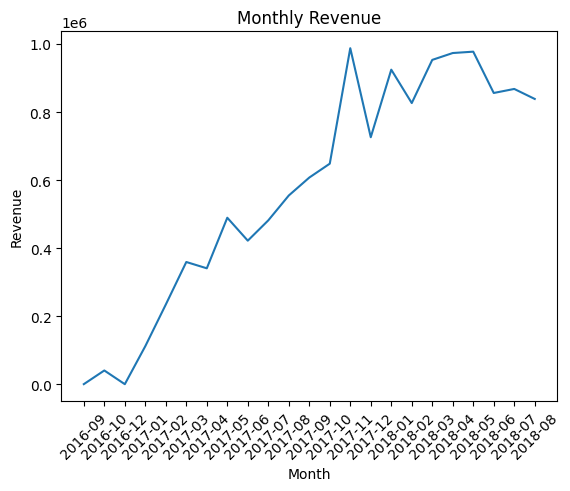

In [12]:
#plot data
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_revenue['month'].astype(str), monthly_revenue['revenue'])
plt.xticks(rotation=45)
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.show()

Revenue shows consistent growth over time with noticeable seasonal spikes.

In [14]:
#Product Category Analysis
category_revenue = (df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False).head(20))

category_revenue

product_category_name
beleza_saude              1233131.72
relogios_presentes        1166176.98
cama_mesa_banho           1023434.76
esporte_lazer              954852.55
informatica_acessorios     888724.61
moveis_decoracao           711927.69
utilidades_domesticas      615628.69
cool_stuff                 610204.10
automotivo                 578966.65
brinquedos                 471286.48
ferramentas_jardim         470495.28
bebes                      400421.84
perfumaria                 390144.65
telefonia                  309860.23
moveis_escritorio          268154.31
papelaria                  223788.69
pcs                        218684.14
pet_shop                   211695.64
instrumentos_musicais      184315.74
eletroportateis            182754.12
Name: revenue, dtype: float64

A small number of categories drive a disproportionate share of revenue.

In [15]:
#Region Analysis
state_revenue = (df.groupby('customer_state')['revenue'].sum().sort_values(ascending=False))

state_revenue.head()

customer_state
SP    5067633.16
RJ    1759651.13
MG    1552481.83
RS     728897.47
PR     666063.51
Name: revenue, dtype: float64

Revenue is concentrated in a few key states, suggesting regional demand differences. 